In [3]:
pip install pandas openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\acer\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import re

# file loading
resume_data = pd.read_csv("Downloads/resume_data.csv")
jd_data = pd.read_csv("Downloads/postings.csv")

# remove illegal character
def remove_illegal_chars(text):
    if isinstance(text, str):
        # filtering
        return re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f-\xff]', '', text)
    return text

# cleaning data frame
# safe to apply full data frame
resume_data = resume_data.map(remove_illegal_chars)
jd_data = jd_data.map(remove_illegal_chars)

# creating ExL file
try:
    with pd.ExcelWriter("Combined_Job_Data.xlsx", engine='openpyxl') as writer:
        resume_data.to_excel(writer, sheet_name="Resumes", index=False)
        jd_data.to_excel(writer, sheet_name="Job_Descriptions", index=False)
    print("Okay Done! Combined_Job_Data.xlsx is created...")
except Exception as e:
    print(f"Error logic: {e}")

Okay Done! Combined_Job_Data.xlsx is created...


Feature Extraction

In [5]:
!pip install spacy
!python -m spacy download en_core_web_sm


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\acer\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip
C:\Users\acer\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\confection\__init__.py:38: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1 import BaseModel, Extra, ValidationError, create_model
Traceback (most recent call last):
  File "<frozen runpy>", line 189, in _run_module_as_main
  File "<frozen runpy>", line 148, in _get_module_details
  File "<frozen runpy>", line 112, in _get_module_details
  File "C:\Users\acer\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\spacy\__init__.py", line 13, in <module>
    from . import pipeline  # noqa: F401
    ^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\acer\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\spacy\pipeline\__init__.py", line 1, in <module>
    from .attributeruler import

In [6]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\acer\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd


df_resumes = pd.read_excel("Combined_Job_Data.xlsx", sheet_name="Resumes")
jd_df = pd.read_excel("Combined_Job_Data.xlsx", sheet_name="Job_Descriptions")


print("Resume Sheet Columns:", df_resumes.columns.tolist())
print("JD Sheet Columns:", jd_df.columns.tolist())

Resume Sheet Columns: ['address', 'career_objective', 'skills', 'educational_institution_name', 'degree_names', 'passing_years', 'educational_results', 'result_types', 'major_field_of_studies', 'professional_company_names', 'company_urls', 'start_dates', 'end_dates', 'related_skils_in_job', 'positions', 'locations', 'responsibilities', 'extra_curricular_activity_types', 'extra_curricular_organization_names', 'extra_curricular_organization_links', 'role_positions', 'languages', 'proficiency_levels', 'certification_providers', 'certification_skills', 'online_links', 'issue_dates', 'expiry_dates', '\ufeffjob_position_name', 'educationaL_requirements', 'experiencere_requirement', 'age_requirement', 'responsibilities.1', 'skills_required', 'matched_score']
JD Sheet Columns: ['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'j

In [8]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# data load
df_resumes = pd.read_excel("Combined_Job_Data.xlsx", sheet_name="Resumes")
jd_df = pd.read_excel("Combined_Job_Data.xlsx", sheet_name="Job_Descriptions")

# full text from different resume column
# together important column (skills, career_objective, responsibilities, degree_names) 
resume_cols_to_combine = ['career_objective', 'skills', 'degree_names', 'responsibilities', 'related_skils_in_job']

def combine_resume_cols(row):
    combined = ""
    for col in resume_cols_to_combine:
        if pd.notna(row[col]):
            combined += str(row[col]) + " "
    return combined.strip()

# Bringing all the resume information into one column
df_resumes['full_resume_text'] = df_resumes.apply(combine_resume_cols, axis=1)

# score calculation function
def get_match_score(resume_text, jd_text):
    if not resume_text or not isinstance(jd_text, str):
        return 0
    vectorizer = TfidfVectorizer(stop_words='english')
    tfidf_matrix = vectorizer.fit_transform([resume_text, jd_text])
    similarity = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])
    return round(similarity[0][0] * 100, 2)

# 1st resume & jd test
sample_resume = df_resumes['full_resume_text'][0]
sample_jd = jd_df['description'][0]

score = get_match_score(sample_resume, sample_jd)

print(f"Company: {jd_df['company_name'][0]}")
print(f"Job Title: {jd_df['title'][0]}")
print(f"--- Match Score: {score}% ---")

Company: Corcoran Sawyer Smith
Job Title: Marketing Coordinator
--- Match Score: 2.17% ---


In [9]:
# loop for 1st 100 resume
scores = []
sample_jd = jd_df['description'][0] 

for i in range(len(df_resumes[:100])):
    res_text = df_resumes['full_resume_text'][i]
    match_score = get_match_score(res_text, sample_jd)
    scores.append({
        'Resume_Index': i,
        'Skills': df_resumes['skills'][i],
        'Match_Score': match_score
    })

# new data frame from result
score_df = pd.DataFrame(scores)

# hightest to lowest
top_matches = score_df.sort_values(by='Match_Score', ascending=False)

print("Top 5 Matches for this Job:")
print(top_matches.head(5))

Top 5 Matches for this Job:
    Resume_Index                                             Skills  \
58            58  ['assisted living', 'interpersonal and communi...   
46            46  ['advertising', 'competitive', 'content', 'con...   
86            86  ['Seasoned Leadership', 'Experienced Manager',...   
82            82  ['3D modeling', 'architectural drafting', 'Aut...   
77            77  ['Net, photo, agile, analyst', 'Apple', 'autom...   

    Match_Score  
58        12.99  
46        11.80  
86        11.10  
82        10.98  
77         9.52  


In [10]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

def get_missing_skills(resume_text, jd_text):
    # Converting resumes and JDs to lowercase
    res = str(resume_text).lower()
    jd = str(jd_text).lower()
    
    # Extracting important keywords or words from JD (using N-grams)
# Here we will find 1 to 2 word phrases (e.g. 'data science', 'sql')
    cv = CountVectorizer(ngram_range=(1, 2), stop_words='english')
    cv.fit([jd])
    jd_keywords = cv.get_feature_names_out()
    
    # Check for missing words in the resume
    missing = [word for word in jd_keywords if word not in res]
    
    #  only show the top 10 big or important words
    missing = sorted(missing, key=len, reverse=True)
    return missing[:10]

# tasting
sample_resume = df_resumes['full_resume_text'][0]
sample_jd = jd_df['description'][0]

missing = get_missing_skills(sample_resume, sample_jd)

print(f"Match Score: {score}%")
print("\nTop Missing Skills/Keywords in Resume:")
for skill in missing:
    print(f"- {skill}")

Match Score: 2.17%

Top Missing Skills/Keywords in Resume:
- shiftmonday fridayexperience
- fridayexperience marketing
- administrative marketing
- consideration employment
- planning sponsorshipsour
- deadlinesgraphic design
- marketing extraordinary
- sponsorshipsour company
- coordinator experience
- reputation exceptional


Visual Chart

C:\Users\acer\AppData\Local\Temp\ipykernel_11912\2409883316.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Score', y='Candidate', data=chart_df, palette='magma')


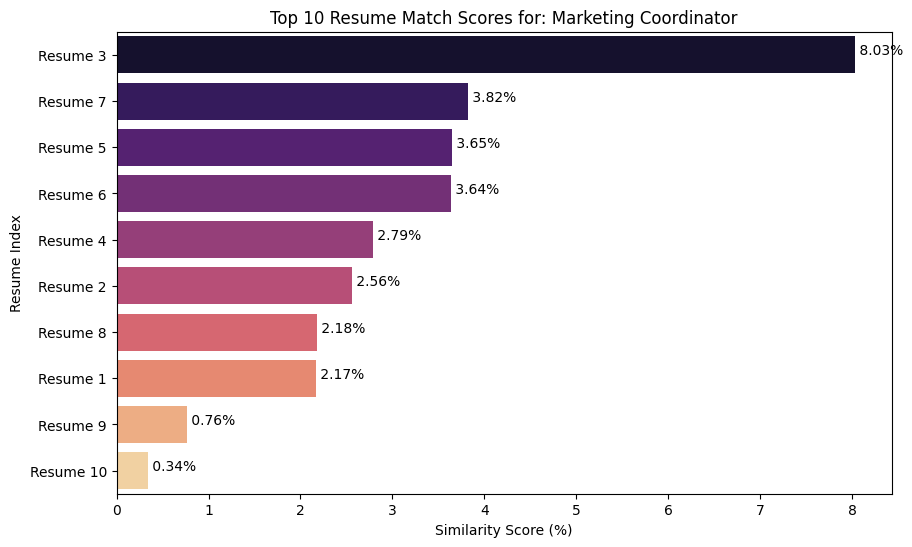

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1st 10 resume score calculate
results = []
sample_jd = jd_df['description'][0]

for i in range(10):
    res_text = df_resumes['full_resume_text'][i]
    score = get_match_score(res_text, sample_jd)
    results.append({'Candidate': f"Resume {i+1}", 'Score': score})

# data frame & sorting
chart_df = pd.DataFrame(results).sort_values(by='Score', ascending=False)

# graph
plt.figure(figsize=(10, 6))
sns.barplot(x='Score', y='Candidate', data=chart_df, palette='magma')
plt.title(f"Top 10 Resume Match Scores for: {jd_df['title'][0]}")
plt.xlabel("Similarity Score (%)")
plt.ylabel("Resume Index")

# value in graph 
for index, value in enumerate(chart_df['Score']):
    plt.text(value, index, f' {value}%')

plt.show()

Clean Keyword Extraction

In [12]:
# targeted skill list
TECH_SKILLS = ['marketing', 'design', 'python', 'sql', 'social media', 'communication', 'management', 'advertising', 'copywriting', 'strategy']

def get_clean_missing_skills(resume_text, jd_text):
    res = str(resume_text).lower()
    jd = str(jd_text).lower()
    
    # skill from jd
    required_skills = [skill for skill in TECH_SKILLS if skill in jd]
    
    # েmissing skill
    missing = [skill for skill in required_skills if skill not in res]
    
    return missing

# results
missing_clean = get_clean_missing_skills(df_resumes['full_resume_text'][0], jd_df['description'][0])
print(f"Actually Missing Key Skills: {missing_clean}")

Actually Missing Key Skills: ['marketing', 'design', 'social media', 'advertising', 'strategy']


Resume Recommendation System

In [13]:
def recommend(score):
    if score >= 70:
        return "Highly Recommended"
    elif score >= 50:
        return "Moderately Suitable"
    else:
        return "Low Match"

score_df["Recommendation"] = score_df["Match_Score"].apply(recommend)

print(score_df.head())

   Resume_Index                                             Skills  \
0             0  ['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...   
1             1  ['Data Analysis', 'Data Analytics', 'Business ...   
2             2  ['Software Development', 'Machine Learning', '...   
3             3  ['accounts payables', 'accounts receivables', ...   
4             4  ['Analytical reasoning', 'Compliance testing k...   

   Match_Score Recommendation  
0         2.17      Low Match  
1         2.56      Low Match  
2         8.03      Low Match  
3         2.79      Low Match  
4         3.65      Low Match  


Skill Gap Report

In [14]:
for i in range(3):
    res_text = df_resumes['full_resume_text'][i]
    missing = get_clean_missing_skills(res_text, sample_jd)

    print(f"\nCandidate {i+1}")
    print("Missing Skills:", missing)


Candidate 1
Missing Skills: ['marketing', 'design', 'social media', 'advertising', 'strategy']

Candidate 2
Missing Skills: ['marketing', 'social media', 'advertising']

Candidate 3
Missing Skills: ['design', 'social media', 'advertising', 'strategy']


Improve Visualization

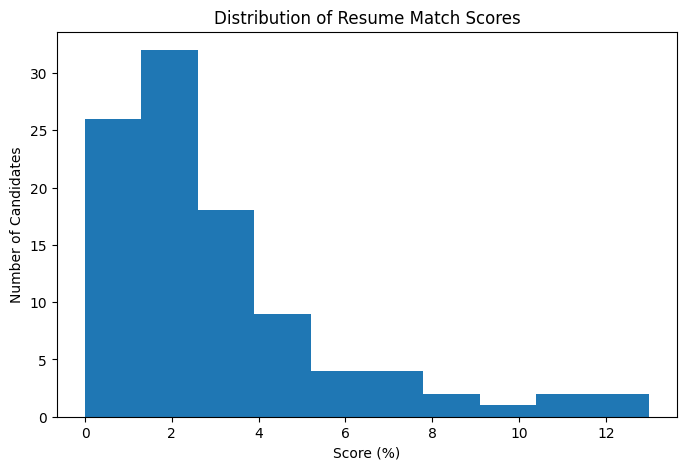

In [15]:
plt.figure(figsize=(8,5))
plt.hist(score_df["Match_Score"], bins=10)
plt.title("Distribution of Resume Match Scores")
plt.xlabel("Score (%)")
plt.ylabel("Number of Candidates")
plt.show()

Build Streamlit App